# Diffusion Demo: Shepp-Logan DDPM

An interactive walk-through of the diffusion stack in this folder:

1. Load a **complex-valued** Shepp-Logan phantom (skimage), optionally resize to
   80x80, impose a smooth linear phase map along the diagonal, and normalize the
   WM magnitude to 1.
2. Synthesize **SNR-controlled** complex Gaussian noise and make noisy phantoms at
   SNR 10 / 30 / 50.
3. Build the **DDPM training framework**, using the GT or a noisy image as ground
   truth `x0`.

Cells are independent: run them top-to-bottom. Training uses the shared `DDPM` /
`UNet` / `DiffusionTrainer` from `ddpm.py` / `unet.py` / `train.py` in this folder.

> The notebook wires imports so that the `diffussion` folder is importable whether
> you launch it from inside `diffussion/` or from the parent `Jupyter/` directory.

## Setup

In [1]:
import sys, os
from pathlib import Path

# Make `diffussion` importable from either the notebook dir or its parent.
DIFF = Path(os.getcwd())
if DIFF.name != "diffussion":
    DIFF = DIFF / "diffussion"
if str(DIFF) not in sys.path:
    sys.path.insert(0, str(DIFF))

import numpy as np
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

device: cuda


In [104]:
# ---- module reload (run after editing any of the .py library files) ----
# We edit ddpm.py / unet.py / train.py frequently, but Python caches a module
# after the first import, so stale definitions persist across cells of this
# notebook. importlib.reload() forces a fresh re-read of the module code, then
# re-imports pull the new classes. Add/chose names as new modules appear.

import importlib
import ddpm, unet, train, dsm
importlib.reload(ddpm)
importlib.reload(unet)
importlib.reload(train)
importlib.reload(dsm)
from ddpm import DDPM
from unet import UNet
from train import DiffusionTrainer
from dsm import DSM, DSMTrainer
print("reloaded ddpm, unet, train, dsm")

reloaded ddpm, unet, train, dsm


## 1.1. Load + normalize the complex Shepp-Logan phantom (WM magnitude = 1)

In [3]:
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

# ---- phantom size --------------------------------------------------------------
# True  -> resize to 80x80 (fast, low memory)
# False -> keep the native shepp-logan resolution (a 10-byte 80x80 id array)
RESIZE_TO_80 = True
NATIVE_SIZE = 400                     # native square size when not resized

phantom_mag = shepp_logan_phantom()
gen_size = 80 if RESIZE_TO_80 else NATIVE_SIZE
phantom_np = resize(phantom_mag, (gen_size, gen_size), anti_aliasing=True,
                    preserve_range=True)
phantom_np = phantom_np.astype(np.float32)

# Build the complex tensor: real magnitude, zero phase to start.
gt = torch.from_numpy(phantom_np)
gt = gt + 1j * torch.zeros_like(gt)             # (H, W) complex64
print("phantom shape:", tuple(gt.shape), "dtype:", gt.dtype, "max:", gt.abs().max().item())

# -------------------------------------------------------------------------
# Optional smooth linear phase map along the diagonal.
#   phase(x, y) = k * (x - y),  with (x, y) in normalized [-1, 1].
# A linear ramp across the image == a linear (voxel-shift) phase gradient along
# the diagonal. `PHASE_SLOPE` is the phase excursion over the full diagonal;
# set to 0.0 for a plain real phantom.
# -------------------------------------------------------------------------
PHASE_SLOPE = 2 * np.pi            # radians over one full diagonal (-pi .. pi)
if PHASE_SLOPE != 0.0:
    ny, nx = gt.shape
    yy, xx = torch.meshgrid(torch.linspace(-1, 1, ny),
                            torch.linspace(-1, 1, nx), indexing="ij")
    diag = (xx - yy)                              # +1 at bottom-right corner
    phase_map = (diag * PHASE_SLOPE / 2.0)     # max|phase| = PHASE_SLOPE/2
    gt = gt * torch.exp(1j * phase_map).to(gt.dtype)

# WM magnitude (the major gray chunk) then normalize so the WM part is magnitude 1.
wm_mask = torch.abs(gt) >= 0.5
wm_mag = torch.abs(gt)[wm_mask].mean()
print(f"WM magnitude (mean over WM mask): {wm_mag:.4f}")

gt_norm = gt / wm_mag
print("max abs (should be ~1.0):", f"{torch.abs(gt_norm).max():.4f}")
if PHASE_SLOPE != 0.0:
    print("phase range [deg]:",
          f"[{torch.rad2deg(torch.angle(gt_norm)).min():.0f},"
          f"{torch.rad2deg(torch.angle(gt_norm)).max():.0f}]")

phantom shape: (80, 80) dtype: torch.complex64 max: 0.9982145428657532
WM magnitude (mean over WM mask): 0.7753
max abs (should be ~1.0): 1.2875
phase range [deg]: [-178,178]


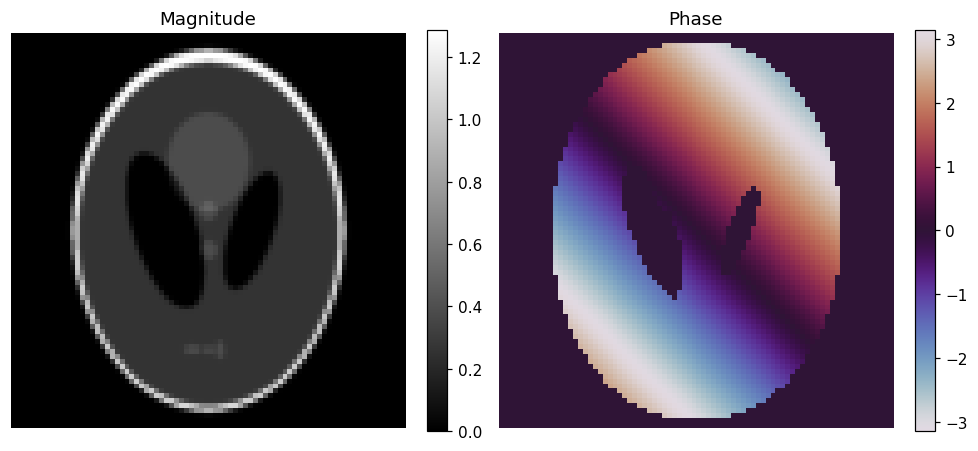

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.2))

im1 = ax1.imshow(torch.abs(gt_norm).numpy(), cmap="gray")
ax1.set_title("Magnitude")
fig.colorbar(im1, ax=ax1, fraction=0.046)
ax1.axis("off")

im2 = ax2.imshow(torch.angle(gt_norm).numpy(), cmap="twilight", vmin=-np.pi, vmax=np.pi)
ax2.set_title("Phase")
fig.colorbar(im2, ax=ax2, fraction=0.046)
ax2.axis("off")

fig.tight_layout()
plt.show()

## 1.2. Noise synthesis: complex i.i.d. Gaussian, strength set by WM SNR

In [5]:
def add_complex_noise(gt, snr, seed=None, ref_mag=1.0):
    """Add complex Gaussian noise to a ground-truth image at a given magnitude SNR.

    Complex i.i.d. Gaussian: noise = (n_re + 1j * n_im) / sqrt(2) * sigma,
    where each of n_re, n_im ~ N(0,1). The magnitude SNR is
        SNR = |signal_reference| / sigma
    so sigma = ref_mag / SNR. With `ref_mag` defaulting to 1.0 (the WM magnitude
    after normalization), `snr` is the WM SNR of the corrupting noise.

    Args:
        gt (complex tensor): (H, W) or (B, H, W) to be corrupted.
        snr (float): WM SNR to realize.
        seed (int, optional): RNG seed for reproducibility.
        ref_mag (float): reference magnitude for the SNR denominator (default 1.0).

    Returns:
        (noisy, noise) with the same shape/dtype as gt.
    """
    if not torch.is_complex(gt):
        raise TypeError("gt must be a complex tensor (a complex Shepp-Logan phantom).")

    sigma = ref_mag / snr
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    n_re = torch.randn(gt.shape, generator=g, dtype=gt.real.dtype)
    n_im = torch.randn(gt.shape, generator=g, dtype=gt.real.dtype)
    noise = (n_re + 1j * n_im) / (2.0 ** 0.5) * sigma
    return gt + noise, noise

In [6]:
SNR_LIST = [10, 30, 50]
noisy = {}   # snr -> noisy image
noise = {}   # snr -> noise map

for snr in SNR_LIST:
    noisy[snr], noise[snr] = add_complex_noise(gt_norm, snr, seed=42)

# Check the SNR actually realized on the WM mask (reality check of the definition).
for snr in SNR_LIST:
    snr_wm = torch.abs(gt_norm)[wm_mask].mean() / torch.std(torch.abs(noise[snr])).item()
    print(f"SNR {snr:>2}:  realized WM-magnitude SNR = {snr_wm:.2f}")

SNR 10:  realized WM-magnitude SNR = 21.69
SNR 30:  realized WM-magnitude SNR = 65.07
SNR 50:  realized WM-magnitude SNR = 108.45


## 1.3. Visualizing ground truth vs. noisy phantoms (magnitude + phase)

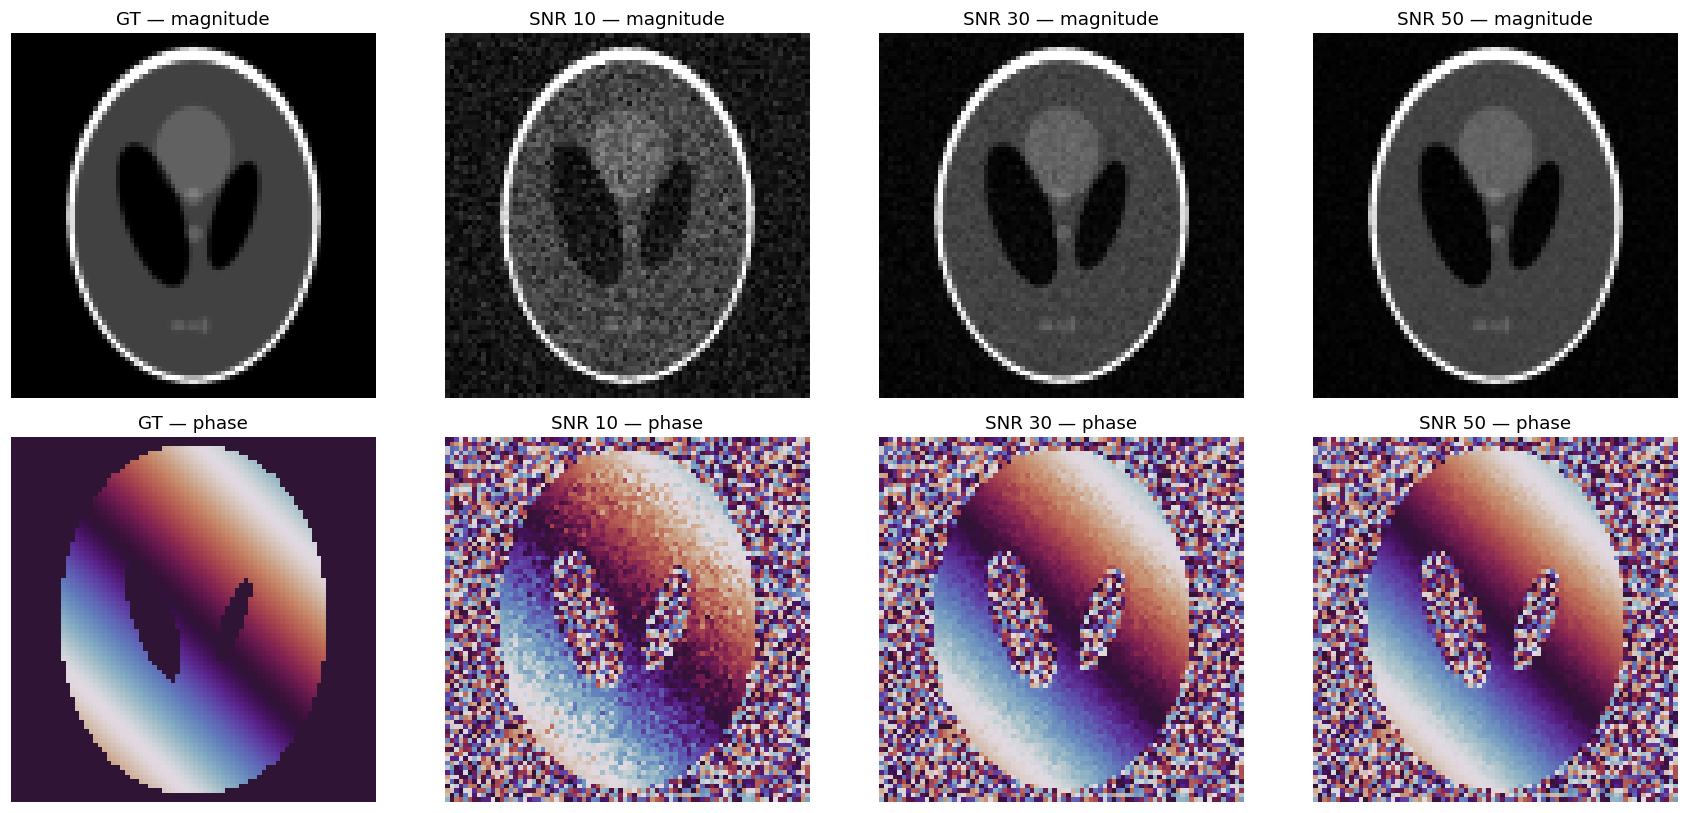

In [7]:
cols = ["GT"] + [f"SNR {s}" for s in SNR_LIST]
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))

for col in range(4):
    im = gt_norm if col == 0 else noisy[SNR_LIST[col - 1]]

    # Magnitude row
    a = axes[0, col]
    a.imshow(torch.abs(im).numpy(), cmap="gray", vmin=0, vmax=1)
    a.set_title(cols[col] + " — magnitude")
    a.axis("off")

    # Phase row
    a = axes[1, col]
    a.imshow(torch.angle(im).numpy(), cmap="twilight", vmin=-np.pi, vmax=np.pi)
    a.set_title(cols[col] + " — phase")
    a.axis("off")

fig.tight_layout()
plt.show()

`gt_norm` (SNR inf) is the noise-free ground truth going forward.

## 1.4. Training framework: DDPM

The DDPM consumes a **2-channel Real/Imag** image of shape `(1, 2, H, W)` (the
`UNet` default is `in_ch=2`). We convert a complex image with `stack([real, imag])`.
The diffusion ground truth `x0` can be the clean GT or any noisy phantom — pick the
source in the cell below via `X0_SNR`.

x0 shape: (1, 2, 80, 80) | source: GT (clean)
x0 per-channel effective scale ([Re, Im]):
  Re: mean = -0.024, std = 0.219, min = -1.285, max = +1.231
  Im: mean = +0.010, std = 0.183, min = -1.135, max = +1.277


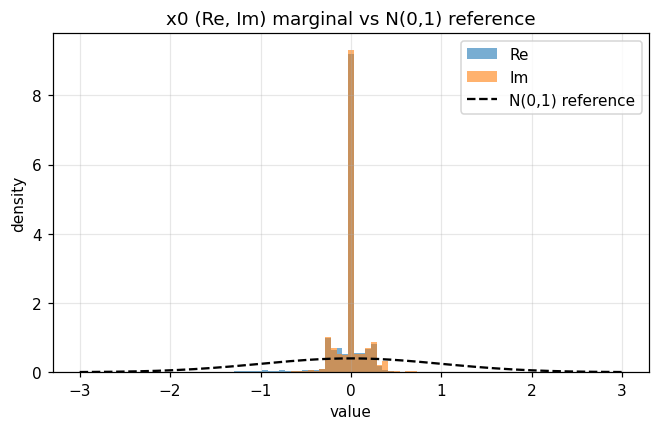

In [10]:
from unet import UNet
from ddpm import DDPM
from train import DiffusionTrainer


def complex_to_two_ch(x):
    """Complex (H, W) -> (1, 2, H, W) float32 (real, imag) channel stack."""
    return torch.stack([x.real, x.imag], dim=0).unsqueeze(0).float()


def two_ch_to_complex(y):
    """(B, 2, H, W) -> complex (B, H, W)."""
    return y[:, 0] + 1j * y[:, 1]


# ---- choose the training ground truth: clean GT (None) or one of the noisy ones ---
X0_SNR = None        # None -> clean GT; else one of [10, 30, 50]
x0_complex = gt_norm if X0_SNR is None else noisy[X0_SNR]
x0 = complex_to_two_ch(x0_complex).to(DEVICE)
print("x0 shape:", tuple(x0.shape), "| source:", "GT (clean)" if X0_SNR is None else f"noisy SNR {X0_SNR}")

# ---- effective scale check on the (Re, Im) channels the network actually sees ----
# The UNet consumes x0 as two real channels [Re, Im]. For a clean forward/reverse
# round trip, each channel should be mean~0 with unit-ish scale, matching the
# N(0,I) noise that seeds the reverse walk. This prints the per-channel stats so
# we can sanity-check that normalization (a literal [-1,1] recenter is NOT needed
# if these already look sane near zero / order 1).
print("x0 per-channel effective scale ([Re, Im]):")
for name, ch in zip(["Re", "Im"], x0[0]):
    print(f"  {name}: mean = {ch.mean().item():+.3f}, std = {ch.std().item():.3f}, "
          f"min = {ch.min().item():+.3f}, max = {ch.max().item():+.3f}")

# ---- visual version: per-channel histograms overlaid vs. the N(0,1) reference ----
# Shows how far x0's Re/Im marginal falls from the unit Gaussian that seeds x_T.
# If both hover just below the unit-gaussian peak, the forward/reverse scales mesh.
import numpy as np
import torch as __torch__  # noqa: F401  (torch is already imported above)

re_ch = x0[0, 0].cpu().numpy().ravel()
im_ch = x0[0, 1].cpu().numpy().ravel()

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-2.5, 2.5, 80)
ax.hist(re_ch, bins=bins, alpha=0.6, density=True, label="Re")
ax.hist(im_ch, bins=bins, alpha=0.6, density=True, label="Im")
# reference N(0,1)
g = np.linspace(-3, 3, 300)
ax.plot(g, np.exp(-0.5 * g ** 2) / np.sqrt(2 * np.pi), "k--",
        label="N(0,1) reference")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title("x0 (Re, Im) marginal vs N(0,1) reference")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [9]:
"""Build the DDPM models for the endpoint A/B comparison.

The ONE variable under test is `ENDPOINT_FRACTION`: whether ~10% of training
iterations are pinned onto the final timestep t = T-1 (the step that assembles the
clean image out of noise).

Everything else is locked to the known-good baseline so the comparison isolates the
endpoint effect:
  - T = 200, beta = (1e-4, 0.02)  -- the schedule that empirically works here,
    NOT the paper's 1000. A short schedule + small net fits one image well.
  - base_out = 32, emb_dim = 32   -- small capacity, enough for 80x80.
  - N_ITERS set in the training cell (default 5000).

We build TWO models on IDENTICAL data/config: one with endpoint enforcement OFF
(endpoint_off) and one ON (endpoint_on). Both are trained in the next cell and
compared in the inference cell. The prior T=1000 experiment degraded because we
removed endpoint-forcing AND lengthened the schedule at the same time; keeping
T=200 while toggling only endpoint isolates what actually helps.

ENDPOINT_FR = 0.10 (ON) / 0.0 (OFF).
    """
ENDPOINT_FR = 0.10                 # A/B fraction: 0.10 -> ON, 0.0 -> OFF
ENDPOINT_REGIMES = {               # label -> fraction (both share the same config)
    "off": 0.00,
    "on":  ENDPOINT_FR,
}
# --------------------------------------------------------------------------
# Gradient clipping: cap the total gradient norm before each Adam step. The
# iteration sweep showed the loss blowing up ~4500 from a random low-t draw;
# clip_grad_norm_(1.0) makes that explosion impossible without altering the
# ordinary (sub-threshold) trajectory. Enabled globally here (same for both
# regimes so it stays a single shared setting).
# --------------------------------------------------------------------------
GRAD_CLIP = 1.0

# Two independent UNets + DDPMs: one per regime, same schedule, same data later.
models = {}
trainers = {}
for tag, fr in ENDPOINT_REGIMES.items():
    bb = UNet(in_ch=2, out_ch=2, base_out=32, emb_dim=32).to(DEVICE)
    m = DDPM(T=200, beta_start=1e-4, beta_end=0.02, backbone=bb, endpoint=fr)
    models[tag] = m
    trainers[tag] = DiffusionTrainer(m, lr=1e-3, device=DEVICE,
                                     grad_clip=GRAD_CLIP)
    print(f"[{tag:>3}] DDPM params: {sum(p.numel() for p in m.net.parameters()):,}, "
          f"endpoint={fr:.2f}, T={m.T}, grad_clip={GRAD_CLIP}, "
          f"final alpha_bar={m.alpha_bar[-1].item():.4e}")

# The shared reverse-sampling step count (MUST be full T for that scheme to decode).
END_T = models["off"].T

[off] DDPM params: 6,630,306, endpoint=0.00, T=200, grad_clip=1.0, final alpha_bar=1.3218e-01
[ on] DDPM params: 6,630,306, endpoint=0.10, T=200, grad_clip=1.0, final alpha_bar=1.3218e-01


## 2.1.a. DDPM training

Because we are training a diffusion *generative* model on a **single** phantom image,
we feed the same `x0` many times. Each iteration samples a random timestep `t` and a
fresh Gaussian `eps`, so even with a single training image the model sees the full
noise level range. Watch the loss drop from ~1 (pure-noise MSE) toward small values.

The loss is the standard DDPM objective `|| eps - eps_theta(x_t, t) ||^2`.

In [ ]:
"""Train BOTH endpoint regimes on the same single-image data (x0).

Each regime gets the same N_ITERS and the same RNG seed, so the ONLY difference
is endpoint enforcement (off vs on). This directly answers whether forcing the
final reverse step is what produces the observed quality jump.

Per-regime losses are logged so you can compare convergence side by side.
"""
N_ITERS = 5000         # training iterations on the single-image dataset
LOG_EVERY = 500        # print the running loss

# Same RNG seed for both regimes so schedule noise exposure is comparable.
torch.manual_seed(0)
all_losses = {}
for tag, m in models.items():
    m.net.train()
    torch.manual_seed(0)      # identical initial t/noise stream per regime
    lss = []
    for it in range(N_ITERS):
        loss = trainers[tag].step(x0)
        lss.append(loss)
        if (it + 1) % LOG_EVERY == 0:
            print(f"[{tag:>3}] iter {it + 1:>5} | loss = {loss:.4f}")
    all_losses[tag] = lss

# Plot both loss curves on the same log-y axes for direct comparison.
plt.figure(figsize=(8, 3.2))
for tag, lss in all_losses.items():
    plt.plot(lss, label=f"endpoint={'ON' if models[tag].endpoint > 0 else 'OFF'}")
plt.xlabel("iteration"); plt.ylabel("DDPM loss (eps-MSE)")
plt.title("Endpoint ON vs OFF convergence (identical single-image data)")
plt.yscale("log"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [ ]:
"""Iteration sweep on the better (OFF) regime: does overtraining hurt sampling?

Train `models['off']` once and checkpoint SAMPLE whenever the iteration count is a
multiple of 500. Each checkpoint uses the FULL reverse walk (steps=END_T) so the
walk never silently skips the low-t decoding.

This run has GRAD_CLIP=1.0 enabled (set in the build cell), so we can verify the
prediction that clipping prevents the ~4500 loss blowup and lets the later
checkpoints hold their quality. If the loss stays flat past 4500 and the samples
don't collapse, the explosion was indeed gradient-driven.
"""
SWEEP_TAG   = "off"        # the better regime from the endpoint A/B
CHECK_EVERY = 500          # sample every 500 iterations
SWEEP_MAX   = 10000        # run to 10000 iterations (20 checkpoints)
SWEEP_SAMPLES = 4          # draws shown per checkpoint

swp = models[SWEEP_TAG]
swp.net.train()
torch.manual_seed(0)        # identical noise stream -> isolation on iterations only

sweep_ckpts = []            # list of (iteration, complex (N, H, W) samples)
sweep_losses = []           # list of (iteration, loss) at each 500 checkpoint

def _sample_now():
    shape = (SWEEP_SAMPLES, 2) + tuple(x0.shape[-2:])
    swp.net.eval()
    torch.manual_seed(0)                    # same noise at every checkpoint
    with torch.no_grad():
        s = swp.sample(shape, steps=END_T, device=DEVICE)
    swp.net.train()                          # back to training mode
    return two_ch_to_complex(s).cpu()        # (N,H,W) complex, CPU for display

for it in range(1, SWEEP_MAX + 1):
    loss = trainers[SWEEP_TAG].step(x0)
    if it % CHECK_EVERY == 0:
        sweep_ckpts.append((it, _sample_now()))
        sweep_losses.append((it, loss))
        print(f"[{SWEEP_TAG}] iter {it:>5} | loss = {loss:.4f}")

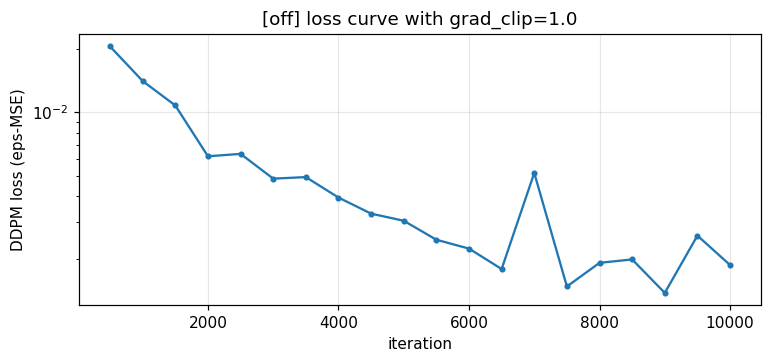

In [117]:
# 'sweep_ckpts' holds (iteration, samples) at 500, 1000, ..., SWEEP_MAX.
# The training-loss curve below is the direct check on the ~4500 blowup.
_its = [li[0] for li in sweep_losses]
_lss = [li[1] for li in sweep_losses]
plt.figure(figsize=(8, 3.2))
plt.plot(_its, _lss, marker="o", ms=3)
plt.xlabel("iteration"); plt.ylabel("DDPM loss (eps-MSE)")
plt.title(f"[{SWEEP_TAG}] loss curve with grad_clip={GRAD_CLIP}")
plt.yscale("log"); plt.grid(alpha=0.3)
plt.show()

In [118]:
"""Save the best (OFF) model so it can be reloaded later without retraining.

Pickles the whole DDPM + UNet under models[SWEEP_TAG] into a single torch state
dict. Note we tag with the iteration count and the regime so a saved file can't
be confused with a different run.

The UNet is a plain nn.Module, so torch.save(model.net.state_dict(), ...) would
also work; saving the whole model keeps the schedule (T, betas) bundled in.
"""
import os

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)
save_path = SAVE_DIR / f"shepp_ddpm_{SWEEP_TAG}_it{SWEEP_MAX}.pt"

torch.save(models[SWEEP_TAG], save_path)
print("saved model:", save_path)
print("file size:", f"{os.path.getsize(save_path) / 1e6:.2f} MB")

saved model: saved_models\shepp_ddpm_off_it10000.pt
file size: 26.59 MB


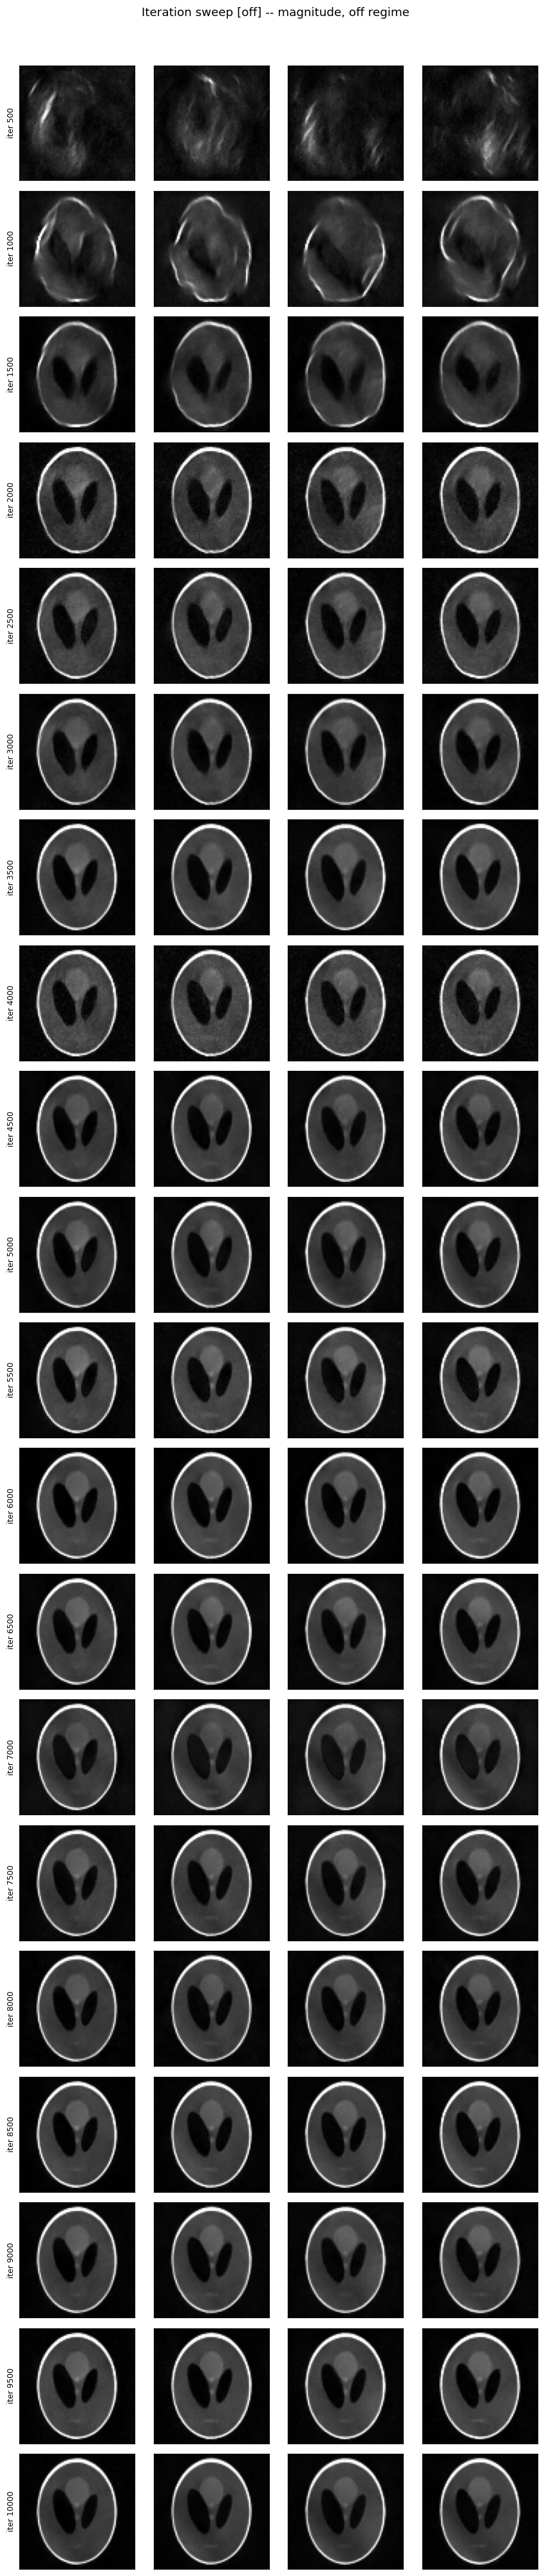

In [116]:
"""Display the iteration sweep: one row per checkpoint, one column per draw.

If the single-image training overfits past some point, you'll see the samples get
sharper/cleaner then degrade or collapse as SWEEP_MAX is approached. Read across,
top = fewest iterations, bottom = most.
"""
_NROW_CAP = SWEEP_MAX // CHECK_EVERY     # exact number of checkpoints the sweep made
sweep_ckpts = sweep_ckpts[-_NROW_CAP:]   # safety trim (should be a no-op)
nrows  = len(sweep_ckpts)
ncol   = SWEEP_SAMPLES

fig, axes = plt.subplots(nrows, ncol, figsize=(2.0 * ncol, 1.8 * nrows))
if nrows == 1:
    axes = axes[None, :]
for ri, (it, cmplx) in enumerate(sweep_ckpts):
    for ci in range(ncol):
        a = axes[ri, ci]
        a.imshow(cmplx[ci].abs().numpy(), cmap="gray", vmin=0, vmax=1)
        a.set_xticks([]); a.set_yticks([])
        if ci == 0:
            a.set_ylabel(f"iter {it}", fontsize=8)
fig.suptitle(f"Iteration sweep [{SWEEP_TAG}] -- magnitude, off regime", y=1.01)
fig.tight_layout()
plt.show()

## 2.1.b. Forward process (time-resolved perturbations of the GT)

The reverse montage (cell 4) shows the walk back to clean. Here we show the
*forward* counterpart: the GT `x0` corrupted step-by-step at increasing `t`, via
`ddpm.perturb`. Snapshot a few spaced timesteps, magnitude + phase, so you can see
how quickly the structure is buried under Gaussian noise as alpha_bar -> 0.

No training involved - just the schedule + fresh random noise. Re-run freely.

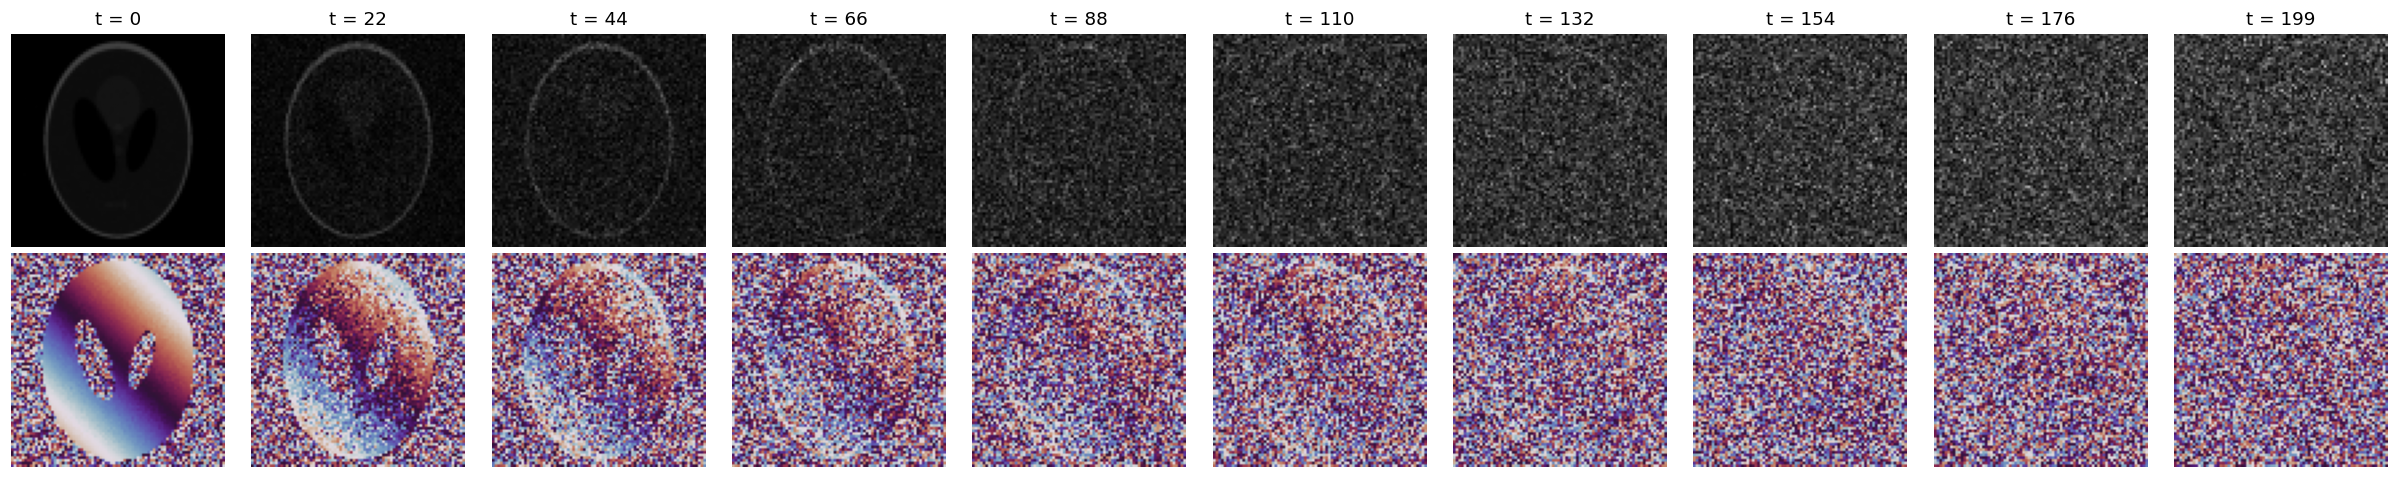

In [11]:
def forward_montage(model, x0, n=10):
    """Corrupt the ground truth x0 at n spaced timesteps; return (t, x_t CPU) list.

    x0 is the (1, 2, H, W) Real/Imag GT on DEVICE. We snapshot x_t at ~n evenly
    spaced t in [0, T), pulled from the model's own linear beta schedule, so the
    walk runs from nearly-clean (small t) to buried-in-noise (large t).
    """
    T = model.T
    ts = torch.linspace(0, T - 1, n).long().tolist()   # spaced timesteps
    snaps = []
    with torch.no_grad():
        for t in ts:
            ts_full = torch.full((x0.shape[0],), t, device=x0.device, dtype=torch.long)
            x_t, _ = model.perturb(x0, ts_full)         # forward: x0 -> x_t (+ eps)
            snaps.append((int(t), x_t.cpu()))
    return snaps

N_FWD = 10                 # snapshots along the forward walk
FWD_TAG = "off"            # which regime's schedule to visualize ("off"/"on")
                           # (both share the same T/betas, so this is cosmetic)
fwd_model = models[FWD_TAG]
fwd = forward_montage(fwd_model, x0, n=N_FWD)   # list of (t, (1,2,H,W) CPU) at spaced t

# Show magnitude (top) and phase (bottom) at each perturbed timestep.
fwd_complex = two_ch_to_complex(torch.cat([f[1] for f in fwd]))  # (B,H,W) complex
fig, axes = plt.subplots(2, len(fwd), figsize=(2.2 * len(fwd), 4.4))
for i, (t, _) in enumerate(fwd):
    a = axes[0, i]
    a.imshow(fwd_complex[i].abs().numpy(), cmap="gray", vmin=0, vmax=5)
    a.set_title(f"t = {t}"); a.axis("off")
    a = axes[1, i]
    a.imshow(torch.angle(fwd_complex[i]).numpy(), cmap="twilight",
             vmin=-np.pi, vmax=np.pi)
    a.axis("off")
axes[0, 0].set_ylabel("magnitude")
axes[1, 0].set_ylabel("phase")
fig.tight_layout()
plt.show()

## 2.1.c. Inference (reverse-process sampling)

After training, generate fresh phantoms by running the reverse process from pure
Gaussian noise. The model's output is the 2-channel `(B,2,H,W)` Real/Imag image,
which we convert back to complex for display. Different random draws give slightly
different phantoms; with the trained model they should all resemble the original
magnitude structure.

In [ ]:
"""Inference: compare reverse-process samples from BOTH endpoint regimes.

Run the full reverse walk (steps=END_T) for each of the two trained models and
render magnitude + phase side by side, so you can eyeball whether endpoint ON
reproduces the clean phantom any better than OFF.

Use the same random noise seed for both so the comparison is apples-to-apples
(given identical starting noise, any quality gap is attributable to training,
not sampling luck).
"""
N_SAMPLES = 4          # draws per regime
SAMPLE_STEPS = END_T   # full T (200); NEVER subsample (see ddpm.sample semantics)

samples = {}   # tag -> complex (N, H, W)
for tag, m in models.items():
    m.net.eval()
    shape = (N_SAMPLES, 2) + tuple(x0.shape[-2:])     # (N, 2, H, W)
    torch.manual_seed(0)          # same noise -> isolate training difference
    with torch.no_grad():
        s = m.sample(shape, steps=SAMPLE_STEPS, device=DEVICE)
    samples[tag] = two_ch_to_complex(s).cpu()
    r = samples[tag].abs()
    print(f"[{tag:>3}] samp abs range: [{r.min():.3f}, {r.max():.3f}]")

# ---- overlay: rows = regime, columns = samples, two panels (mag / phase) ----
tags = list(samples)
ncol = min(N_SAMPLES, 8)
for _tp in ["mag", "phase"]:
    fig, axes = plt.subplots(len(tags), ncol,
                             figsize=(2.4 * ncol, 2.4 * len(tags)))
    if len(tags) == 1:
        axes = axes[None, :]
    for ri, tag in enumerate(tags):
        for ci in range(ncol):
            a = axes[ri, ci]
            if _tp == "mag":
                a.imshow(samples[tag][ci].abs().numpy(), cmap="gray",
                         vmin=0, vmax=1)
            else:
                a.imshow(torch.angle(samples[tag][ci]).numpy(),
                         cmap="twilight", vmin=-np.pi, vmax=np.pi)
            a.set_title(f"[{tag}] sample {ci} {_tp}", fontsize=9)
            a.axis("off")
    fig.suptitle(f"{_tp} -- endpoint OFF (top) vs ON (bottom)", y=1.02)
    fig.tight_layout()
    plt.show()

[off] samp abs range: [0.000, 1.359]


In [24]:
print(samples.shape)

torch.Size([4, 80, 80])


Sampling abs range: [0.000, 1.359]
Axes(0.125,0.11;0.168478x0.77)
Axes(0.327174,0.11;0.168478x0.77)
Axes(0.529348,0.11;0.168478x0.77)
Axes(0.731522,0.11;0.168478x0.77)


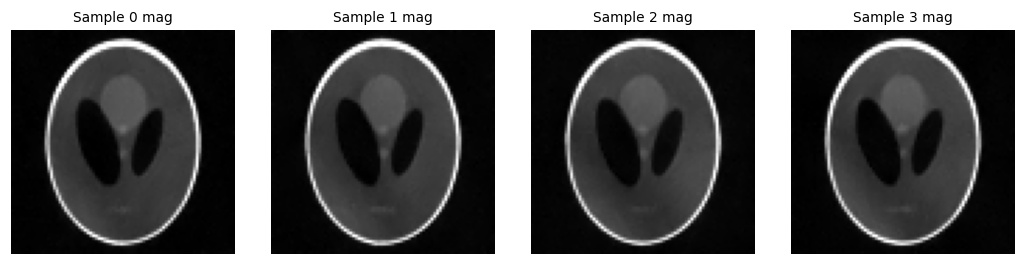

Axes(0.125,0.11;0.168478x0.77)
Axes(0.327174,0.11;0.168478x0.77)
Axes(0.529348,0.11;0.168478x0.77)
Axes(0.731522,0.11;0.168478x0.77)


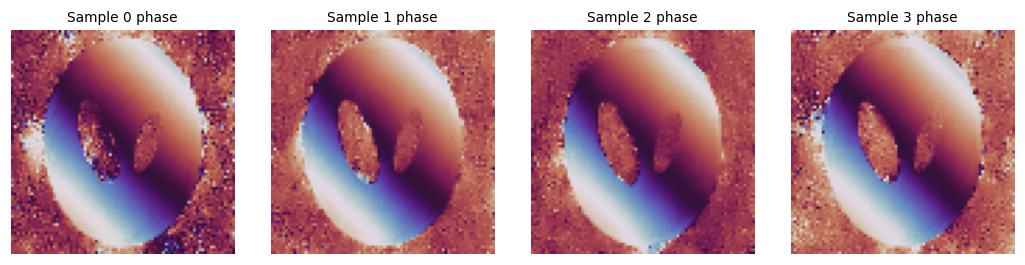

In [26]:
"""Inference: demonstrate the single Shepp-Logan DDPM of 10000 iterations.

Run the full reverse walk (steps=END_T) for the single Shepp-Logan DDPM.

Use the same random noise seed for both so the comparison is apples-to-apples
(given identical starting noise, any quality gap is attributable to training,
not sampling luck).
"""
N_SAMPLES = 4          # draws per regime
SAMPLE_STEPS = END_T   # full T (200); NEVER subsample (see ddpm.sample semantics)

shepp_logan_ddpm = torch.load('saved_models/shepp_ddpm_off_it10000.pt', weights_only=False)

shepp_logan_ddpm.net.eval()
shape = (N_SAMPLES, 2) + tuple(x0.shape[-2:])     # (N, 2, H, W)
torch.manual_seed(0)          # same noise -> isolate training difference
with torch.no_grad():
    s = shepp_logan_ddpm.sample(shape, steps=SAMPLE_STEPS, device=DEVICE)
samples = two_ch_to_complex(s).cpu()
r = samples.abs()
print(f"Sampling abs range: [{r.min():.3f}, {r.max():.3f}]")

# ---- overlay: rows = regime, columns = samples, two panels (mag / phase) ----
ncol = N_SAMPLES
for _tp in ["mag", "phase"]:
    fig, axes = plt.subplots(1, ncol,
                             figsize=(2.4 * ncol, 2.4))
    for ci in range(ncol):
        a = axes[ci]
        print(a)
        if _tp == "mag":
            a.imshow(samples[ci].abs().numpy(), cmap="gray",
                        vmin=0, vmax=1)
        else:
            a.imshow(torch.angle(samples[ci]).numpy(),
                        cmap="twilight", vmin=-np.pi, vmax=np.pi)
        a.set_title(f"Sample {ci} {_tp}", fontsize=9)
        a.axis("off")
    # fig.suptitle(f"{_tp} -- endpoint OFF (top) vs ON (bottom)", y=1.02)
    fig.tight_layout()
    plt.show()

## 2.1.d. Reverse-process montage (denoising across timesteps)

The `DDPM.sample()` above returns only the final image. Here we run the reverse
loop *by hand* and snapshot `x_t` at a few timesteps, so you can watch the walk
from pure noise to the phantom. This is the same posterior update as `sample()`,
just keeping intermediates.

Timesteps are shown in reverse (high `t` = noisy, toward `t = 0` = clean).
`N_STEPS` is how many reverse steps to actually take (shorter = coarser, faster).

In [ ]:
N_MONTAGE = 10          # snapshots to keep along the reverse walk
N_STEPS = END_T         # reverse steps: MUST equal full T (200) -- DDPM's posterior
                        # walk counts DOWN from t=T-1, so fewer steps skip the low-t
                        # decoding entirely and never reach the image.
MONTAGE_TAG = "on"      # which regime's model to walk ("off"/"on")
MONTAGE_IDX = 0         # which image array to feed the snapshot (if we run several)

m_model = models[MONTAGE_TAG]
m_model.net.eval()
torch.manual_seed(0)          # global RNG, matched to the training/inference cells

x = torch.randn((1, 2) + tuple(x0.shape[-2:]), device=DEVICE)
snap = []                      # list of (t_value, x_cpu)
snap_done = set()
monthly = max(1, N_STEPS // N_MONTAGE)   # snapshot every `monthly` reverse steps

for i in range(min(N_STEPS, m_model.T)):
    t = m_model.T - 1 - i
    ts = torch.full((1,), t, device=DEVICE, dtype=torch.long)
    eps_pred = m_model.net(x, ts)
    b, al = m_model.betas[t], m_model.alphas[t]
    so = m_model.sqrt_one_minus_alpha_bar[t]
    x = torch.rsqrt(al + 1e-8) * (x - (b / so) * eps_pred)
    if t > 0:
        x = x + torch.sqrt(m_model.betas[t]) * torch.randn_like(x)
    # Snapshot right after producing x_t (keep ~N_MONTAGE entries).
    if (i % monthly == 0) and (t not in snap_done):
        snap.append((t, x.detach().cpu())); snap_done.add(t)

fig, axes = plt.subplots(1, len(snap), figsize=(2.4 * len(snap), 2.4))
for (t, s), a in zip(snap, axes):
    a.imshow((s[0, 0] + 1j * s[0, 1]).abs().numpy(), cmap="gray", vmin=0, vmax=1)
    a.set_title(f"t = {t}")
    a.axis("off")
fig.suptitle(f"Reverse process [{MONTAGE_TAG}]: noise -> phantom (magnitude)", y=1.02)
fig.tight_layout()
plt.show()

## 2.2.a. Denoising Score Matching (DSM) — score-based validation on the same single phantom

The DDPM above learns an *epsilon-prediction* network and decodes via the reverse
posterior walk. DSM (SMLD, Song &amp; Ermon 2019) instead learns the **score** (gradient
of the log-density of the noise-perturbed data) across a **geometric (log-spaced)
sigma schedule**, and decodes via **annealed overdamped Langevin dynamics**:

    q_sigma(x_tilde | x) = N(x_tilde ; x, sigma^2 I)          # forward perturbation
    x_tilde             = x + sigma * eps                       # per-channel
    DSM loss (SMLD Eq.34) = || sigma * s_theta(x_tilde, sigma) + eps ||^2
    Langevin update       = x + 0.5 * alpha * s_theta + sqrt(alpha) * z,  alpha ~ eps*(sigma/sigma_max)^2

It reuses the **same UNet backbone** (now outputting a score field, conditioned on
the noise *level* index `i`), the same `DiffusionTrainer`, and the same single
phantom `x0` — so this section is a direct, apples-to-apples validation of the DSM
training + inference pipeline against the DDPM we already vetted.

In [77]:
"""Build the DSM / score-based model on the SAME single phantom (x0).

Mirrors the DDPM build cell: one UNet backbone, but DSM conditions the net on a
noise *level index* i and treats the output as a score (SMLD). We lock the config
to the known-good small capacity and use the same gradient-clip knob so this stays
a direct apples-to-apples validation of the DSM pipeline.

DSM now trains under the multi-level batch regime (Option A): each gradient step
feeds a minibatch where every element carries its OWN noise level i (a per-sample
vector), sweeping fine..coarse sigmas in one step. The training loop is a bespoke
`DSMTrainer` (in dsm.py), NOT the shared `DiffusionTrainer`, so the DDPM pipeline
is fully untouched and the same loop generalizes to a true multi-image batch.

Key config:
  - L = 20  log-spaced sigma levels.
  - sigma in [0.01, 0.45]. RETRAIN: sigma_max lowered from 1.2 -> 0.45 (see the
    DSM_SIGMA_MAX edit). The clip experiment (trajectory + inference, no retrain)
    showed the coarse end of the OLD model (sigma_max=1.2) was wildly out-of-
    distribution: the poor-quality coarse score was |grad|~50, blowing |x| to
    ~13.6 at the top level. 0.45 is ~4.5x the data std (0.219) -- the largest
    sigma that keeps the phantom "just buried" (the forward-process cell showed
    full disappearance around ratio ~6), so the prior stays near the data and the
    coarse levels should no longer run away. We first evaluate whether a better
    sigma_max materially helps; ONLY THEN layer on predictor-corrector.
  - base_out = 32, emb_dim = 32  -- same capacity as the DDPM build.
  - lr = 3e-4 on the bespoke DSMTrainer.

This cell is self-contained: GRAD_CLIP is (re)defined here so the DSM branch does
not depend on a particular DDPM build cell having run first.
"""
# Gradient clipping: cap the total gradient norm before each Adam step. The DDPM
# iteration sweep showed the loss blowing up ~4500 from a random low-t draw;
# clip_grad_norm_(1.0) makes that explosion impossible without altering the
# ordinary (sub-threshold) trajectory. DSM trains on a single sample with L noise
# levels, so the same occasional-large-gradient protection carries over.
GRAD_CLIP = 1.0

DSM_SIGMA_MIN = 0.01
# RETRAIN: sigma_max 1.2 -> 0.45 (~4.5x data std 0.219). Old coarse end was OOD
# (|grad|~50, |x|->13.6). 0.45 keeps the phantom just-buried -> prior tied to data.
DSM_SIGMA_MAX = 0.66
DSM_L         = 20
DSM_LR        = 3e-4
N_ITERS       = 10000
# Multi-level minibatch size. Kept equal to L so each batch holds EXACTLY one copy
# of every noise level 0..L-1: a random permutation of L levels covers the whole
# range uniformly, with no level duplicated or starved. For a true multi-image
# batch later, set DSM_BATCH to a multiple of L (e.g. 32 with L=16) so each sweep
# still covers every level once -- same scheme, just more copies per sweep.
DSM_BATCH     = DSM_L

dsm_backbone = UNet(in_ch=2, out_ch=2, base_out=32, emb_dim=32).to(DEVICE)
dsm_model    = DSM(L=DSM_L, sigma_min=DSM_SIGMA_MIN, sigma_max=DSM_SIGMA_MAX,
                   backbone=dsm_backbone)
print(f"DSM backbone params: {sum(p.numel() for p in dsm_model.net.parameters()):,}")
print(f"sigma schedule: {dsm_model.sigmas[0]:.4f} .. {dsm_model.sigmas[-1]:.2f} "
      f"over L={dsm_model.L} log-spaced levels")

# Bespoke multi-level DSM trainer (NOT DiffusionTrainer) so the DDPM pipeline is
# unaffected. lr lowered from 1e-3 to DSM_LR to tame the per-iteration overshoot.
dsm_trainer = DSMTrainer(dsm_model, lr=DSM_LR, device=DEVICE, grad_clip=GRAD_CLIP)

DSM backbone params: 6,630,306
sigma schedule: 0.0100 .. 0.66 over L=20 log-spaced levels


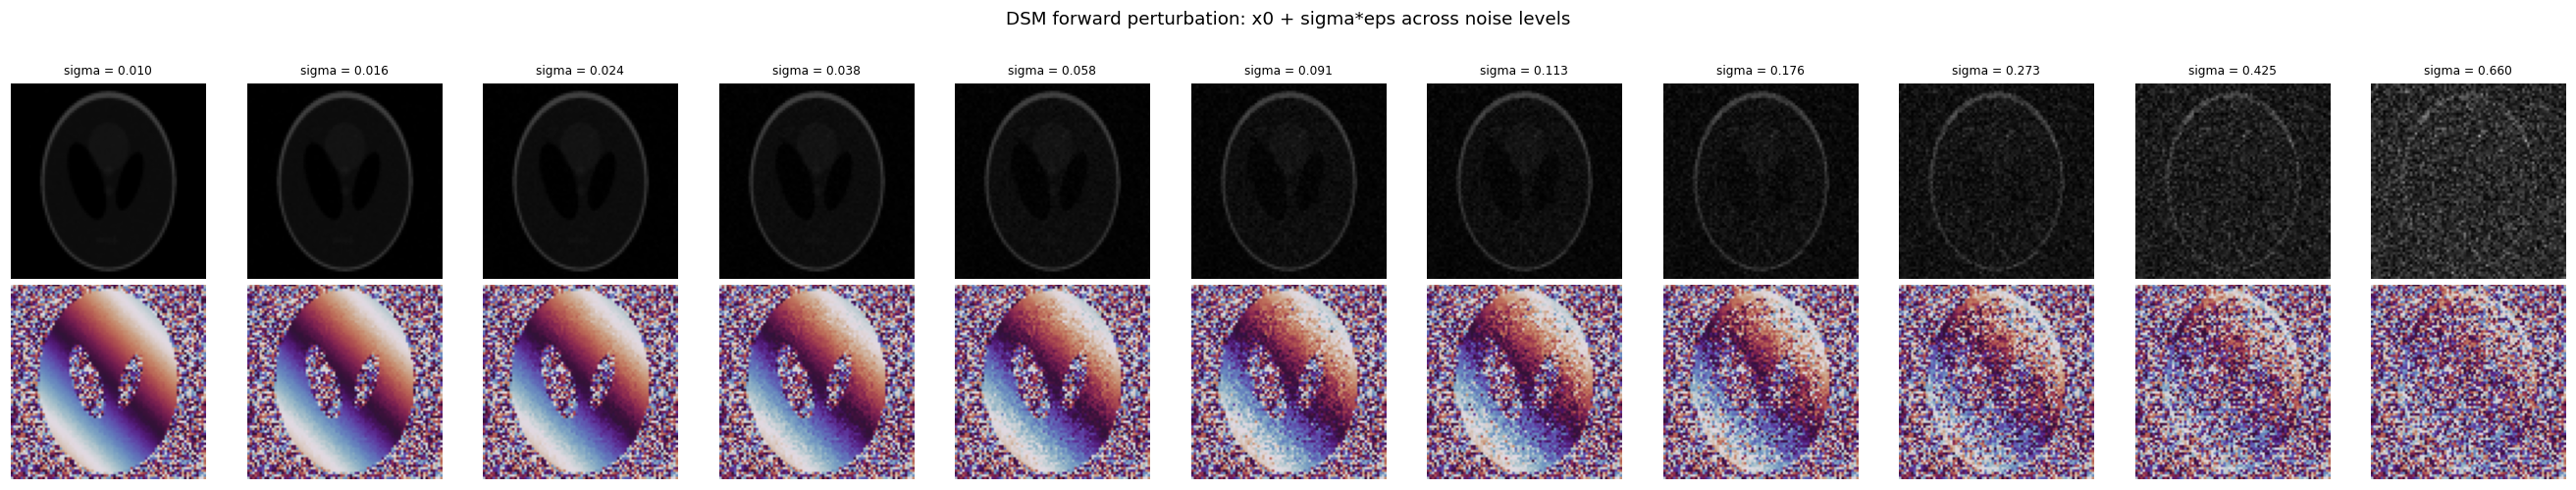

per-channel std of x0 (Re, Im): 0.219, 0.183
sigma= 0.010 | rel-noise sigma/std_Re =  0.05x | perturbed |abs| range [0.00, 1.30]
sigma= 0.016 | rel-noise sigma/std_Re =  0.07x | perturbed |abs| range [0.00, 1.31]
sigma= 0.024 | rel-noise sigma/std_Re =  0.11x | perturbed |abs| range [0.00, 1.32]
sigma= 0.038 | rel-noise sigma/std_Re =  0.17x | perturbed |abs| range [0.00, 1.34]
sigma= 0.058 | rel-noise sigma/std_Re =  0.27x | perturbed |abs| range [0.00, 1.38]
sigma= 0.091 | rel-noise sigma/std_Re =  0.41x | perturbed |abs| range [0.00, 1.45]
sigma= 0.113 | rel-noise sigma/std_Re =  0.52x | perturbed |abs| range [0.00, 1.52]
sigma= 0.176 | rel-noise sigma/std_Re =  0.80x | perturbed |abs| range [0.00, 1.72]
sigma= 0.273 | rel-noise sigma/std_Re =  1.25x | perturbed |abs| range [0.00, 2.03]
sigma= 0.425 | rel-noise sigma/std_Re =  1.94x | perturbed |abs| range [0.00, 2.53]
sigma= 0.660 | rel-noise sigma/std_Re =  3.01x | perturbed |abs| range [0.01, 3.52]


In [78]:
"""DSM forward process: perturb the GT x0 at each noise level and watch quality.

The DDPM forward montage (cell 4) snaps x_t along timesteps t. DSM's forward
counterpart is the geometric sigma sweep: for each level i we draw
    x_tilde_i = x0 + sigma_i * eps        (DSM.perturb)
so the image is progressively buried under N(0, sigma_i^2) Gaussian noise as i
goes from fine (small sigma) to coarse (large sigma). This is the exact training
distribution the score network sees, so the walk shows how much of the phantom
survives at each sigma -- and, importantly, at which level the structure is fully
swallowed (that sigma is the coarsest the sampler should start from).

No model involved -- just the schedule + fresh noise. Re-run freely. The level
indices and their sigma values come straight from dsm_model (built above), so
this stays consistent if SIGMA_MIN/MAX/L change.
"""
N_FWD_LEVELS = 11                     # how many levels to snapshot along 0..L-1
PERT_SEED    = 0                      # seeded so the noise draw is fixed & comparable

# Pick ~evenly-spaced level indices across the FULL sigma range [fine .. coarse].
lvl_idx = [round(i * (dsm_model.L - 1) / (N_FWD_LEVELS - 1))
           for i in range(N_FWD_LEVELS)]

rows = []                             # list of (sigma, x_tilde complex (H,W) CPU)
with torch.no_grad():
    for i in lvl_idx:
        i_vec = torch.full((x0.shape[0],), i, device=x0.device, dtype=torch.long)
        torch.manual_seed(PERT_SEED)
        x_tilde, _, sigma = dsm_model.perturb(x0, i_vec)
        rows.append((sigma.item(), two_ch_to_complex(x_tilde).cpu()))

# Render magnitude (top) + phase (bottom) across the sweep.
fig, axes = plt.subplots(2, len(rows), figsize=(2.2 * len(rows), 4.4))
for col, (sig, xc) in enumerate(rows):
    a = axes[0, col]
    a.imshow(xc[0].abs().numpy(), cmap="gray", vmin=0, vmax=5)
    a.set_title(f"sigma = {sig:.3f}", fontsize=8); a.axis("off")
    a = axes[1, col]
    a.imshow(torch.angle(xc[0]).numpy(), cmap="twilight", vmin=-np.pi, vmax=np.pi)
    a.axis("off")
axes[0, 0].set_ylabel("magnitude")
axes[1, 0].set_ylabel("phase")
fig.suptitle("DSM forward perturbation: x0 + sigma*eps across noise levels", y=1.02)
fig.tight_layout()
plt.show()

# Numerical summary: per-channel std and MPI (mean-per-image) count of how much
# noise drowns the structure -- the phantom is essentially gone once sigma is
# several x the per-channel std of x0 (Re ~0.22, Im ~0.18 from the diagnostics).
print("per-channel std of x0 (Re, Im):",
      f"{x0[0,0].std().item():.3f}, {x0[0,1].std().item():.3f}")
for sig, xc in rows:
    print(f"sigma={sig:6.3f} | rel-noise sigma/std_Re = {sig/x0[0,0].std().item():5.2f}x",
          f"| perturbed |abs| range [{xc.abs().min():.2f}, {xc.abs().max():.2f}]")

In [79]:
# Per-step minibatch: same phantom repeated, each copy at its OWN noise level.
# DSM_BATCH == DSM_L, so one random permutation of [0..L) places exactly one copy
# of every level in the batch -- no duplication, no starvation.
x_batch = x0.repeat(DSM_BATCH, 1, 1, 1)      # (DSM_BATCH, 2, H, W) on DEVICE

torch.manual_seed(0)          # same seed as the DDPM runs -> comparable convergence
dsm_model.net.train()
losses = []
for it in range(N_ITERS):
    # Fresh random permutation of [0..L) each step; every level appears once.
    i_vec = torch.randperm(DSM_L).to(DEVICE)
    loss = dsm_trainer.step(x_batch, i_vec)
    losses.append(loss)
    if (it + 1) % LOG_EVERY == 0:
        print(f"[DSM] iter {it + 1:>5} | loss = {loss:.4f}")

[DSM] iter   500 | loss = 0.2694
[DSM] iter  1000 | loss = 0.1320
[DSM] iter  1500 | loss = 0.0781
[DSM] iter  2000 | loss = 0.0507
[DSM] iter  2500 | loss = 0.0357
[DSM] iter  3000 | loss = 0.0269
[DSM] iter  3500 | loss = 0.0209
[DSM] iter  4000 | loss = 0.0171
[DSM] iter  4500 | loss = 0.0148
[DSM] iter  5000 | loss = 0.0136
[DSM] iter  5500 | loss = 0.0117
[DSM] iter  6000 | loss = 0.0110
[DSM] iter  6500 | loss = 0.0094
[DSM] iter  7000 | loss = 0.0084
[DSM] iter  7500 | loss = 0.0079
[DSM] iter  8000 | loss = 0.0076
[DSM] iter  8500 | loss = 0.0066
[DSM] iter  9000 | loss = 0.0064
[DSM] iter  9500 | loss = 0.0064
[DSM] iter 10000 | loss = 0.0056


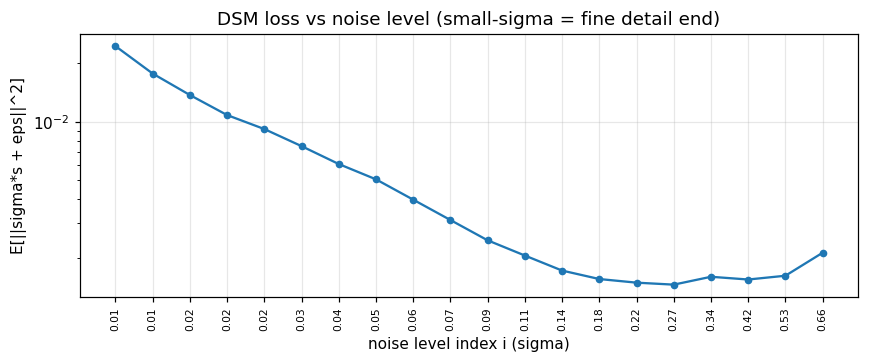

per_level: 0.025 0.018 0.014 0.011 0.009 0.007 0.006 0.005 0.004 0.003 0.002 0.002 0.002 0.002 0.001 0.001 0.002 0.002 0.002 0.002


In [80]:
"""Per-level DSM loss: does the score network denoise well at EVERY sigma?

The multi-level training above sweeps all levels each step, but here we decompose
the result — evaluate E[|| sigma*s + eps ||^2] separately at each of the L levels,
on the SAME phantom. This is the key DSM validation: a score model is only as good
as its worst sigma, and SMLD notoriously under-trains the finest (small-sigma)
levels.

If the small-sigma levels have a markedly higher loss than the mid/large ones,
that is a *conditioning* problem specific to DSM (the network must pick a noise
direction out of a nearly-clean signal), not a generic overfitting issue.
"""
with torch.no_grad():
    dsm_model.net.eval()

    per_level = []
    for i in range(dsm_model.L):
        # i_vec: a single-element vector for this one level
        i_vec = torch.full((x0.shape[0],), i, device=x0.device, dtype=torch.long)
        # average over a few eps draws at this level
        _l = 0.0
        K = 20
        for _ in range(K):
            x_tilde, eps, sigma = dsm_model.perturb(x0, i_vec)
            scores = dsm_model.net(x_tilde, i_vec)
            _l += torch.nn.functional.mse_loss(scores * sigma.view(-1, 1, 1, 1),
                                               -eps).item()
        per_level.append(_l / K)

    dsm_model.net.train()

plt.figure(figsize=(8, 3.4))
plt.semilogy(range(dsm_model.L), per_level, marker="o", ms=4)
plt.xticks(range(dsm_model.L),
           [f"{dsm_model.sigmas[i].item():.2f}" for i in range(dsm_model.L)],
           rotation=90, fontsize=7)
plt.xlabel("noise level index i (sigma)"); plt.ylabel("E[||sigma*s + eps||^2]")
plt.title("DSM loss vs noise level (small-sigma = fine detail end)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("per_level:", " ".join(f"{v:.3f}" for v in per_level))

In [110]:
"""Save the best (OFF) model so it can be reloaded later without retraining.

Pickles the whole DDPM + UNet under models[SWEEP_TAG] into a single torch state
dict. Note we tag with the iteration count and the regime so a saved file can't
be confused with a different run.

The UNet is a plain nn.Module, so torch.save(model.net.state_dict(), ...) would
also work; saving the whole model keeps the schedule (T, betas) bundled in.
"""
import os

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)
save_path = SAVE_DIR / f"shepp_dsm_it10000.pt"

torch.save(dsm_model, save_path)
print("saved model:", save_path)
print("file size:", f"{os.path.getsize(save_path) / 1e6:.2f} MB")

saved model: saved_models\shepp_dsm_it10000.pt
file size: 26.58 MB


## 2.2.b. DSM inference — annealed Langevin sampling

After training, generate fresh phantoms via the DSM reverse process: annealed
**overdamped Langevin dynamics** over the L noise levels (SMLD Algorithm 1). Start
from pure Gaussian noise at the coarsest scale `sigma_max`, then walk down each
level toward the data. The network output is the (2-channel) score field, which we
convert back to complex for display — exactly the DDPM inference cells, but with
`dsm.sample` instead of `ddpm.sample`.

Note the sampler has two knobs the DDPM didn't:
  - `steps` — total Langevin updates (SMLD defaults to T_anneal per level).
  - `eps`  — the Langevin step-size scale (too large -> diverges / too small -> no
    exploration). We start at a conservative default and show the trajectory below.

DSM sample abs range: [0.000, 1.336]


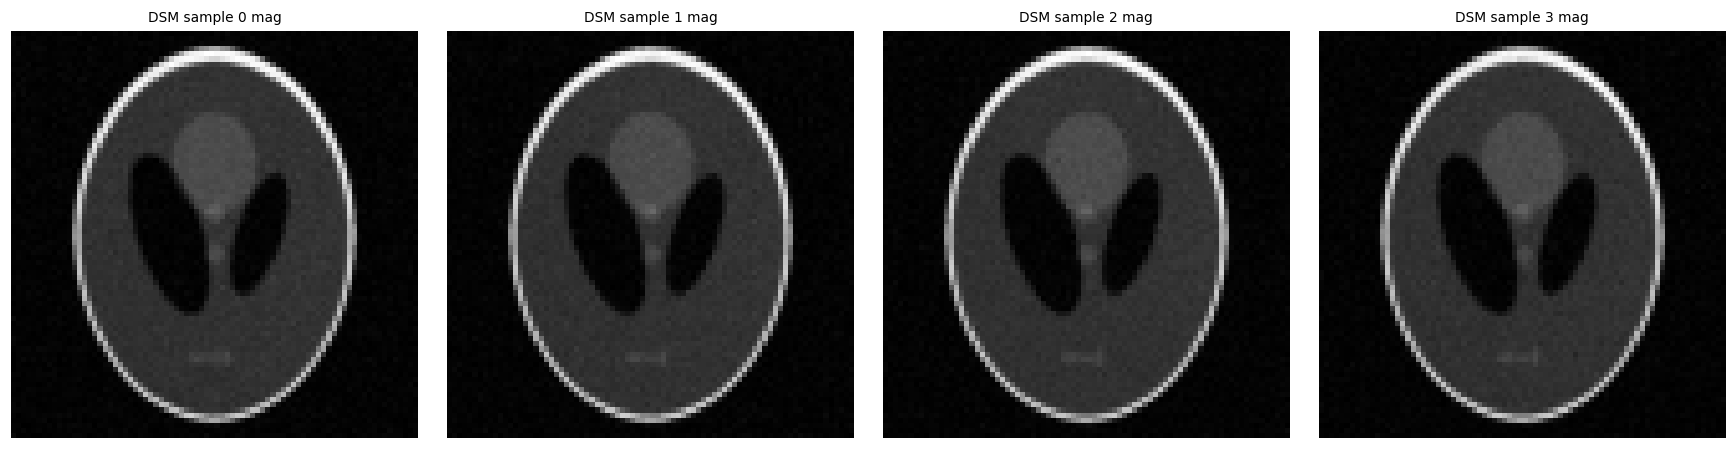

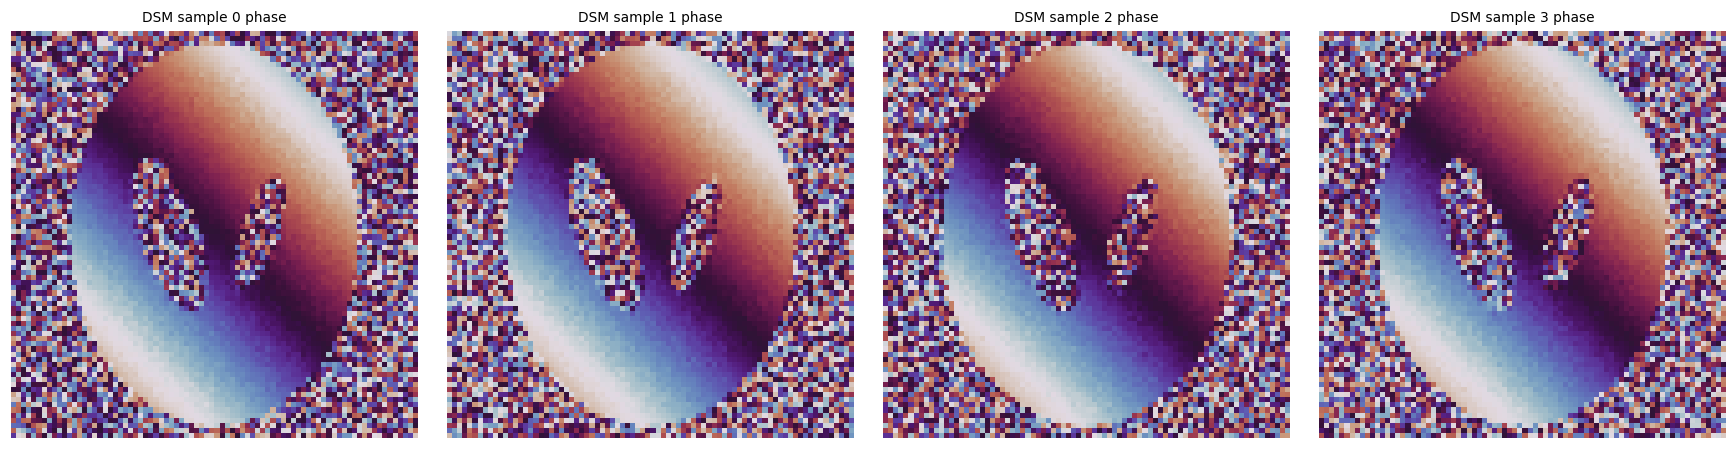

In [109]:
"""DSM inference: predictor-corrector Langevin samples (SMLD Alg 2).

Concept: annealed overdamped Langevin decoding over the L noise levels. Start from
pure noise at the coarsest level (sigma_max = 0.66 after the retrain) and walk DOWN
through every level to the data, using dsm_model.sample.

This is now the PREDICTOR-CORRECTOR sampler (SMLD Algorithm 2), which supersedes
the pure annealed Langevin (Algorithm 1): at each level one predictor step anneals
coarse->fine, then a corrector block of DSM_STEPS_CORRECTOR Langevin iterations
settles the walk onto the sigma_i + quantization manifold at FIXED sigma_i before
the next descent. This blocks the fine-level collapse that pure annealed Langevin
hit (fixed eps + long anneal accumulated ~O(sigma_max) random walk at the finest
levels and re-perturbed the just-built phantom).

KNOBS:
  - corrector_steps (DSM_STEPS_CORRECTOR): corrector Langevin iterations per level.
  - eps (DSM_EPS): Langevin step-size scale (the balanced value the diagnostics
    ~1.0). See dsm.sample default eps and the corrector step-size note.
  - steps / T_anneal are OVERRIDDEN by the explicit coarse->fine level loop in
    sample(); kept only to match the trajectory cell's interface.
"""
N_SAMPLES     = 4
DSM_STEPS     = 1000 * dsm_model.L     # retained for interface match (level loop overrides)
DSM_EPS       = 1                  # Langevin step-size scale
DSM_T_ANNEAL  = 1000               # retained for interface match
DSM_STEPS_CORRECTOR = 5            # corrector iterations per level (SMLD Alg 2)

dsm_model.net.eval()
shape = (N_SAMPLES, 2) + tuple(x0.shape[-2:])     # (N, 2, H, W)
torch.manual_seed(0)
with torch.no_grad():
    s = dsm_model.sample(shape, steps=DSM_STEPS, eps=DSM_EPS,
                         T_anneal=DSM_T_ANNEAL, device=DEVICE,
                         corrector_steps=DSM_STEPS_CORRECTOR)
dsm_samples = two_ch_to_complex(s).cpu()          # (N, H, W) complex
r = dsm_samples.abs()
print(f"DSM sample abs range: [{r.min():.3f}, {r.max():.3f}]")

# ---- render magnitude + phase, one row per draw ----
for _tp in ["mag", "phase"]:
    fig, axes = plt.subplots(1, N_SAMPLES, figsize=(4 * N_SAMPLES, 4))
    for ci in range(N_SAMPLES):
        a = axes[ci]
        if _tp == "mag":
            a.imshow(dsm_samples[ci].abs().numpy(), cmap="gray")
        else:
            a.imshow(torch.angle(dsm_samples[ci]).numpy(),
                     cmap="twilight", vmin=-np.pi, vmax=np.pi)
        a.set_title(f"DSM sample {ci} {_tp}", fontsize=9)
        a.axis("off")
    fig.tight_layout()
    plt.show()

## 2.2.c. DSM Langevin trajectory (noise → phantom across sigma levels)

Where the DDPM reverse montage snapshots *timesteps* `t`, DSM's trajectory runs
across *noise levels* `i` (sigma descending). We reproduce the DDPM montage here
for DSM: run the annealed Langevin loop by hand and snapshot `x` at a few points
along the walk, from sigma_max (pure noise) down to sigma_min (clean).

This shows the score field actually guiding the walk toward the phantom — the
central claim of the score-based (SMLD) pipeline. `DSM_SNAPSHOTS` picks how many
intermediate `x` to keep; `DSM_T_ANNEAL` is the Langevin step count per level.

sampler: sigma_max=0.660  eps=1.00e+00  T_anneal=1000  corrector=5  L=20
per-level diagnostics (per-channel rms):
lvl   sigma   |drift|   |noise|  noise/dr    |grad|   |walk|
  0   0.010  1.43e-02  1.51e-02       1.1  1.25e+02    0.203
  1   0.012  1.95e-02  1.89e-02       1.0  1.09e+02    0.205
  2   0.016  2.48e-02  2.35e-02       0.9  8.95e+01    0.206
  3   0.019  3.17e-02  2.95e-02       0.9  7.35e+01    0.207
  4   0.024  3.95e-02  3.65e-02       0.9  5.89e+01    0.208
  5   0.030  4.85e-02  4.55e-02       0.9  4.66e+01    0.210
  6   0.038  5.93e-02  5.69e-02       1.0  3.67e+01    0.212
  7   0.047  7.35e-02  7.08e-02       1.0  2.92e+01    0.217
  8   0.058  9.24e-02  8.81e-02       1.0  2.36e+01    0.223
  9   0.073  1.18e-01  1.11e-01       0.9  1.94e+01    0.233
 10   0.091  1.50e-01  1.38e-01       0.9  1.59e+01    0.248
 11   0.113  1.90e-01  1.71e-01       0.9  1.29e+01    0.267
 12   0.141  2.38e-01  2.14e-01       0.9  1.04e+01    0.297
 13   0.176  2.97e-01  2.64e-01 

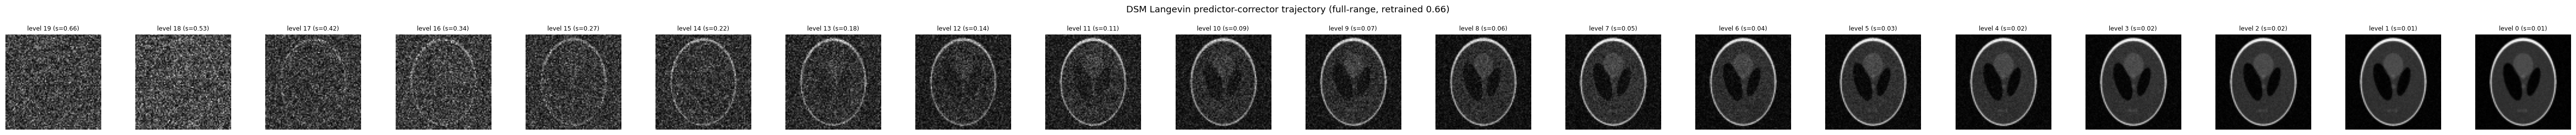

In [105]:
"""DSM Langevin trajectory + sampler diagnostics (predictor-corrector, SMLD Alg 2).

Two jobs in this cell:
  A) Snapshot x as sigma descends (noise -> phantom) -- the visual trajectory.
  B) Instrument the walk to expose WHY it may stall. The score is already verified
     good (recovery below the perfect-score floor at every level), so a broken
     fine end after a good score points at the step-size balance. For each level
     we measure:
       1. walk std  ||x||   vs. that level's noise sigma  -> does x actually
          descend toward sigma_min, or is it stuck at ~sigma_max?
       2. score magnitude  ||s(i)||  at the current x     -> is there a real
          gradient to follow?
       3. drift-vs-noise ratio:  ||0.5*alpha*s||  vs.  ||sqrt(alpha)*z||.
          If noise >> drift the walk is diffusive (random), not descending; if
          noise << drift it overshoots / runs away. A converged SMLD anneal wants
          drift of the same order as (or just above) the injected noise.

PREDICTOR-CORRECTOR (SMLD Algorithm 2), matching dsm.sample: for each level i,
  - one *predictor* step anneals the walk DOWN from coarse sigma_(i) to the next
    finer sigma;
  - a *corrector* block of DSM_TRAJ_CORRECTOR Langevin iterations then settles the
    walk onto the sigma_i + quantization manifold at FIXED sigma_i, before the
    next descent. This blocks the fine-level collapse: previously (pure annealed
    Langevin, eps fixed) the finest levels accumulated a sqrt(time)*sqrt(alpha) ~
    O(sigma_max) random walk that re-perturbed/erased the freshly-built phantom
    (|walk| collapsed to 0.021 at level 0 while |grad| exploded to ~119). The
    corrector's per-level Langevin steps keep the drift/noise balance pinned to
    the local sigma scale (~sigma·sqrt(alpha)), never adding cumulative coarse
    noise.

LEVEL ORDER: sigma DESCENDS coarse->fine (SMLD Algorithm 2). i starts at i_max
(sigma_max), the level queried as the walk progresses moves DOWN toward i=0
(sigma_min). This is the SAME corrected anneal as dsm.sample -- the generative
walk must start with high noise (global structure) and anneal down to low noise
(detail). The seed x is drawn at sigma_max.
"""
import math

DSM_SNAPSHOTS    = 10        # how many intermediate x to keep (visual)
DSM_TRAJ_ANNEAL  = 1000      # Langevin steps per level (contiguous, matching sample)
DSM_TRAJ_EPS     = 1         # step-size scale (match the inference cell)
DSM_TRAJ_CORRECTOR = 5       # corrector Langevin iterations per level (SMLD Alg 2)

dsm_model.net.eval()
sigmas    = dsm_model.sigmas
sigma_max = sigmas[-1].item()          # full-range sigma_max (0.66 after retrain)
i_max     = dsm_model.L - 1

# ---- per-level diagnostics accumulators (mean-square over the whole image) ----
diag_acc = {}
for i in range(dsm_model.L):
    diag_acc[i] = dict(drift=0.0, noise=0.0, grad=0.0, walk=0.0, n=0)

# Snapshot points in the OVERALL loop step budget. With the corrector, each level
# runs (1 + DSM_TRAJ_CORRECTOR) Langevin updates, so the total is:
Ltot = DSM_TRAJ_ANNEAL * dsm_model.L          # not used for indexing below

snap_pts = {}
for k in range(DSM_SNAPSHOTS + 1):
    snap_pts[k] = True                        # one snapshot at the END of each level band

traj = []                # (level i, sigma, x_cpu) for the visual mount

def _langevin_step():
    """One overdamped Langevin update at the CURRENT (level i, sigma s_, x)."""
    global x
    alpha = DSM_TRAJ_EPS * (s_ / sigma_max) ** 2
    ts = torch.full((1,), i, device=DEVICE, dtype=torch.long)
    with torch.no_grad():
        grad = dsm_model.net(x, ts)
    z = torch.randn_like(x)
    drift = 0.5 * alpha * grad
    noise = (alpha ** 0.5) * z
    x = x + drift + noise
    # accumulate level-i statistics
    a = diag_acc[i]
    a["drift"] += drift.square().mean().item()
    a["noise"] += noise.square().mean().item()
    a["grad"]  += grad.square().mean().item()
    a["walk"]  += x.square().mean().item()
    a["n"]     += 1

# Seed at the highest noise (sigma_max).
x = torch.randn((1, 2) + tuple(x0.shape[-2:]), device=DEVICE) * sigma_max

# ---- predictor-corrector anneal: coarse -> fine ----
for step_i, i in enumerate(range(i_max, -1, -1)):
    s_ = sigmas[i].item()
    # predictor: one anneal step at level i (queries level i, descends next)
    _langevin_step()
    # corrector: settle onto the sigma_i manifold at fixed sigma_i
    for _ in range(DSM_TRAJ_CORRECTOR):
        _langevin_step()
    traj.append((i, s_, x.detach().cpu()))

dsm_model.net.train()

# ---- print the per-level balance (the diagnostic table) ----
print("sampler: sigma_max=%.3f  eps=%.2e  T_anneal=%d  corrector=%d  L=%d"
      % (sigma_max, DSM_TRAJ_EPS, DSM_TRAJ_ANNEAL, DSM_TRAJ_CORRECTOR, dsm_model.L))
print("per-level diagnostics (per-channel rms):")
print(f"{'lvl':>3} {'sigma':>7} {'|drift|':>9} {'|noise|':>9} "
      f"{'noise/dr':>9} {'|grad|':>9} {'|walk|':>8}")
for i in range(dsm_model.L):
    a = diag_acc[i]
    n = max(1, a["n"])
    drift_r = math.sqrt(a["drift"] / n)
    noise_r = math.sqrt(a["noise"] / n)
    grad_r  = math.sqrt(a["grad"]  / n)
    walk_r  = math.sqrt(a["walk"]  / n)
    ratio   = noise_r / (drift_r + 1e-12)
    print(f"{i:>3} {sigmas[i].item():7.3f} {drift_r:9.2e} {noise_r:9.2e} "
          f"{ratio:9.1f} {grad_r:9.2e} {walk_r:8.3f}")

# ---- visual trajectory: magnitude at each snapshot (one per level) ----
fig, axes = plt.subplots(1, len(traj), figsize=(2.4 * len(traj), 2.4))
for (i, _sig, xcpu), a in zip(traj, axes):
    a.imshow((xcpu[0, 0] + 1j * xcpu[0, 1]).abs().numpy(), cmap="gray")
    a.set_title(f"level {i} (s={_sig:.2f})", fontsize=8)
    a.axis("off")
fig.suptitle("DSM Langevin predictor-corrector trajectory (full-range, retrained 0.66)", y=1.02)
fig.tight_layout()
plt.show()

In [112]:
# Print the score model's sigma schedule and where the first few levels sit.
# The effective data scale is x0's per-channel std (Re 0.219, Im 0.183); the
# coarsest level sigma_max pins the prior. Run after the (re)train so this always
# reflects the CURRENT sigma_max (changed to 0.45 for the retrain experiment).
print("x0 channel std (Re, Im):", f"{x0[0,0].std().item():.3f}, ",
      f"{x0[0,1].std().item():.3f}",
      "| sigma_max ratio:",
      f"{(dsm_model.sigmas[-1].item() / max(x0[0,0].std(), x0[0,1].std())):.2f}")
for ii in range(dsm_model.L):
    print(f"level {ii:>2}: sigma = {dsm_model.sigmas[ii].item():.4f}")

x0 channel std (Re, Im): 0.219,  0.183 | sigma_max ratio: 3.01
level  0: sigma = 0.0100
level  1: sigma = 0.0125
level  2: sigma = 0.0155
level  3: sigma = 0.0194
level  4: sigma = 0.0242
level  5: sigma = 0.0301
level  6: sigma = 0.0375
level  7: sigma = 0.0468
level  8: sigma = 0.0584
level  9: sigma = 0.0728
level 10: sigma = 0.0907
level 11: sigma = 0.1131
level 12: sigma = 0.1410
level 13: sigma = 0.1758
level 14: sigma = 0.2191
level 15: sigma = 0.2732
level 16: sigma = 0.3406
level 17: sigma = 0.4246
level 18: sigma = 0.5294
level 19: sigma = 0.6600


torch.Size([1, 2, 80, 80])


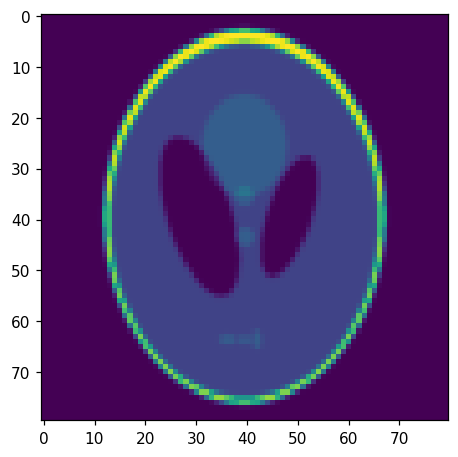

In [118]:
print(eps.shape)
plt.plot()
plt.imshow((x0[0, 0] + 1j * x[0, 1]).cpu().abs().numpy())
plt.imshow((x_tilde[0, 0] - sigma * eps[0, 0] + 1j * (x_tilde[0, 1] - sigma * eps[0, 1])).cpu().abs().numpy())
plt.show()

recovery L2 err per level (0..L-1):
0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0001 0.0001 0.0002 0.0003 0.0004 0.0009
(smaller = better recovered; coarse/noisy levels 16-19 stay large by design)


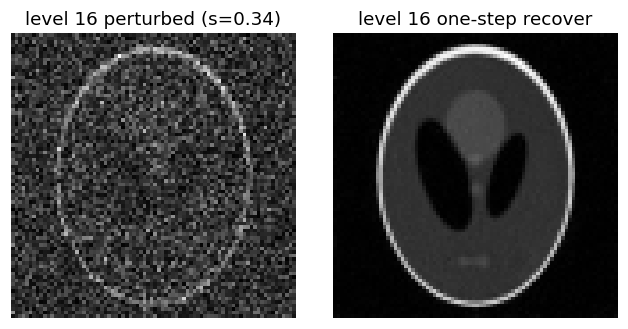

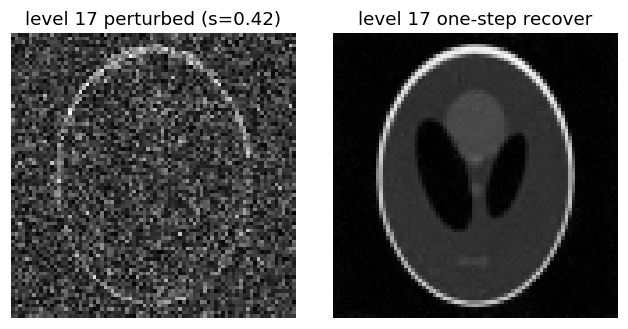

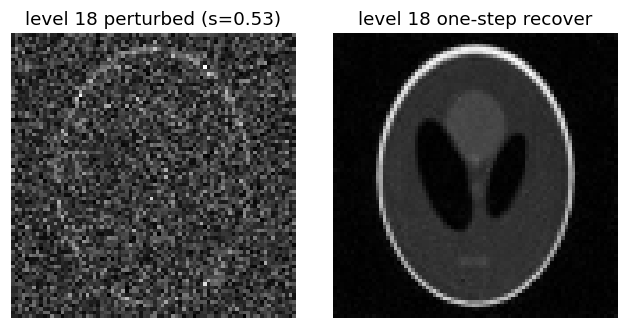

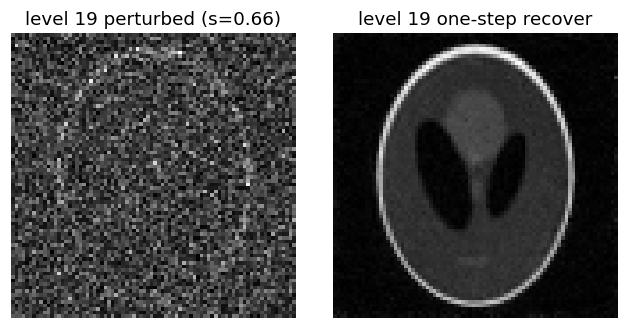

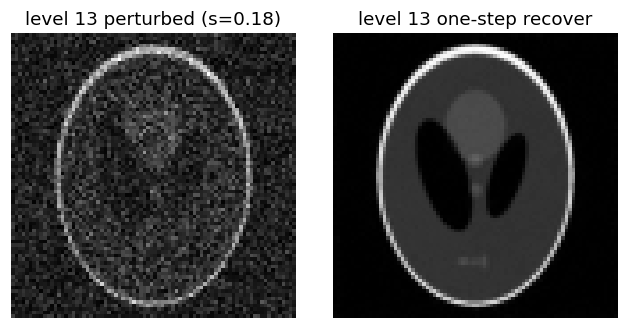

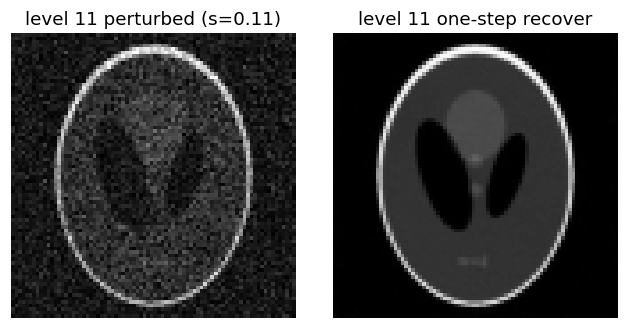

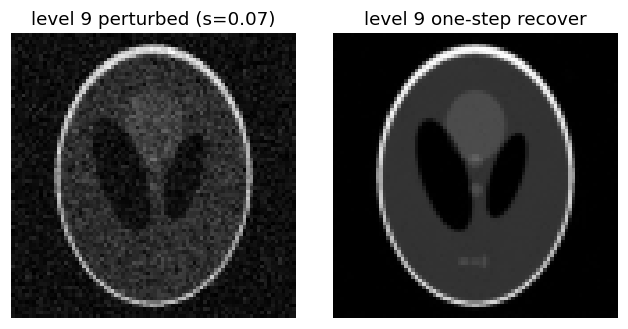

In [122]:
"""Perturb-and-recover across a sweep of sigma levels (Tweedie one-step denoise).

Network convention (dsm.py loss, SMLD Eq.34): loss = || sigma*s_theta + eps ||^2,
so the learned output at (x_tilde, sigma) satisfies sigma*s_theta ~= -eps, i.e.
    s_theta(x_tilde, sigma) ~= -eps/sigma = -(x_tilde - x0)/sigma^2
is the (denoising) score. One-step recovery is the Tweedie correction:
    recover = x_tilde + sigma^2 * s_theta(x_tilde, sigma)
            = (x0 + sigma*eps) + sigma^2 * (-eps/sigma)
            = x0                                    (exact, in expectation)

NB: the naive `x_tilde - sigma*s` would give x_tilde + eps = x0 + (sigma+1)*eps,
i.e. it INJECTS MORE noise -- that is what made every single-step recovery render
as pure noise. We use the +sigma^2*s form here.

Sweep the FULL level range and print E[||recover - x0||^2] on the SAME VOXELS
(not masked), so a phantom that is pure noise (high L2) vs. recovered (low L2) is
unambiguous.

VISUAL RECOVERY: the previous version rendered only levels 16-19 (sigma 0.34-0.66),
which are the MOST noisy coarse levels -- those recovered images stay blurry/noisy
and never show the phantom. We now also render a band of MID/LOW sigma levels
(default 9..16, sigma ~0.07..0.34, where one-step recovery is clean) and show
PERTURBED vs RECOVERED side-by-side so recovery is directly visible as a phantom
emerging from the perturbed field.
"""
REC_K = 20                     # eps draws averaged per level for the L2 error
# Render recovered magnitude at these levels. 16-19 = coarse/noisy (original);
# 9..16 = mid/low sigma where one-step recovery is clean and shows the phantom.
REC_SHOW = [16, 17, 18, 19, 13, 11, 9]

with torch.no_grad():
    dsm_model.net.eval()
    rec_err = []
    rec_targets = {}
    for i in range(dsm_model.L):
        i_vec = torch.full((x0.shape[0],), i, device=x0.device, dtype=torch.long)
        err = 0.0
        for _ in range(REC_K):
            x_tilde, eps, sigma = dsm_model.perturb(x0, i_vec)
            s = dsm_model.net(x_tilde, i_vec)
            # Tweedie one-step denoise: s ~= -eps/sigma  =>  x_tilde + sigma^2*s = x0
            recover = x_tilde + (sigma.view(-1, 1, 1, 1) ** 2) * s
            err += (recover - x0).square().mean().item()
            if i in REC_SHOW:
                rec_targets.setdefault(i, (x_tilde, recover))
        rec_err.append(err / REC_K)
    dsm_model.net.train()

print("recovery L2 err per level (0..L-1):")
print(" ".join(f"{e:.4f}" for e in rec_err))
print("(smaller = better recovered; coarse/noisy levels 16-19 stay large by design)")

# Render PERTURBED vs RECOVERED magnitude side by side for the chosen levels,
# so the phantom visibly re-emerges from the perturbed field at clean levels.
for i in REC_SHOW:
    if i not in rec_targets:
        continue
    x_tilde, recover = rec_targets[i]
    pert = (x_tilde[0, 0] + 1j * x_tilde[0, 1]).abs().detach().cpu()
    rec  = (recover[0, 0] + 1j * recover[0, 1]).abs().detach().cpu()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(6, 3))
    a1.imshow(pert.numpy(), cmap="gray"); a1.set_title(
        f"level {i} perturbed (s={dsm_model.sigmas[i].item():.2f})")
    a1.axis("off")
    a2.imshow(rec.numpy(), cmap="gray"); a2.set_title(
        f"level {i} one-step recover")
    a2.axis("off")
    fig.tight_layout()
    plt.show()